# Приоритизация обращений

В этом ноутбуке я решаю задачу ранжирования обращений. Для каждого обращения я оцениваю вероятность успешного целевого действия в течение пяти дней после назначения. Чем выше `score`, тем выше обращение должно находиться в списке своего дня.

Итоговый файл содержит ровно два столбца.

- `lead_id` с идентификатором обращения из `test.csv`
- `score` с числом от 0 до 1

Основная метрика задания — Daily Average Precision. Для неё важен порядок обращений, а не порог классификации.

Главный anti-leakage барьер выглядит так.

```text
event_ts < assignment_ts
```

Я применяю этот фильтр **до любой агрегации событий**. Я не использую события после назначения, ручную разметку test, внешние API, большие языковые модели и правила для отдельных `lead_id`.

В финальном решении я объединил Ordered CatBoost и XGBoost.

## Содержание ноутбука

1. Загружаю данные и проверяю их структуру
2. Провожу EDA и отдельно проверяю риск утечки будущего
3. Реализую точную метрику Daily Average Precision
4. Создаю признаки из исходной таблицы и `events.csv`
5. Проверяю качество на будущих датах
6. Обучаю финальный ансамбль

## 0. Окружение и переносимые пути

Из-за воспроизводимости, я решил предусмотреть несколько вариантов расположения данных (сам я работал на kaggle).

1. Путь из переменной окружения `LEAD_CHALLENGE_DIR`
2. Указанный Kaggle Dataset `/kaggle/input/datasets/mihailivanovvvv/avito-entry-test/lead_prioritization_challenge`
3. Папка проекта рядом с ноутбуком
4. Локальный путь `challenge_data/lead_prioritization_challenge`

На Kaggle я сохраняю результаты в `/kaggle/working`. При локальном запуске я использую папку `outputs`. Другой выходной каталог можно передать через `LEAD_OUTPUT_DIR`.

In [1]:
from __future__ import annotations

import os
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from catboost import CatBoostClassifier
from scipy.stats import ks_2samp
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
plt.style.use("seaborn-v0_8-whitegrid")

print("pandas", pd.__version__)
print("NumPy", np.__version__)
print("XGBoost", xgb.__version__)

pandas 2.3.3
NumPy 2.0.2
XGBoost 3.2.0


In [2]:
REQUIRED_FILES = (
    Path("data/train.csv"),
    Path("data/test.csv"),
    Path("data/events.csv"),
    Path("sample_submission.csv"),
)


def is_dataset_root(path: Path) -> bool:
    return path.is_dir() and all((path / relative).is_file() for relative in REQUIRED_FILES)


def resolve_input_dir() -> Path:
    candidates = []
    environment_path = os.getenv("LEAD_CHALLENGE_DIR")
    if environment_path:
        candidates.append(Path(environment_path).expanduser())

    current = Path.cwd()
    candidates.extend(
        [
            Path(
                "/kaggle/input/datasets/mihailivanovvvv/avito-entry-test/"
                "lead_prioritization_challenge"
            ),
            current,
            current / "lead_prioritization_challenge",
            current.parent / "lead_prioritization_challenge",
            current / "challenge_data" / "lead_prioritization_challenge",
        ]
    )
    checked = []
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in checked:
            continue
        checked.append(candidate)
        if is_dataset_root(candidate):
            return candidate
    paths = "\n".join(f"  - {path}" for path in checked)
    raise FileNotFoundError(
        "Я не смог найти корень датасета. Я проверил пути\n"
        f"{paths}\n"
        "Укажите путь через LEAD_CHALLENGE_DIR"
    )


def resolve_output_dir() -> Path:
    environment_path = os.getenv("LEAD_OUTPUT_DIR")
    if environment_path:
        return Path(environment_path).expanduser().resolve()
    kaggle_working = Path("/kaggle/working")
    return kaggle_working if kaggle_working.is_dir() else Path.cwd() / "outputs"


@dataclass(frozen=True)
class Config:
    input_dir: Path
    output_dir: Path
    target: str = "target"
    id_col: str = "lead_id"
    user_col: str = "user_id"
    date_col: str = "assignment_date"
    ts_col: str = "assignment_ts"
    seed: int = 42
    thread_count: int = 4
    run_cv: bool = True
    cat_cv_iterations: int = 3000
    xgb_cv_iterations: int = 5000
    cat_final_iterations: int = 2300
    xgb_final_iterations: int = 1300
    cat_weight: float = 0.75
    xgb_weight: float = 0.25


CFG = Config(input_dir=resolve_input_dir(), output_dir=resolve_output_dir())
CFG.output_dir.mkdir(parents=True, exist_ok=True)
np.random.seed(CFG.seed)

TRAIN_PATH = CFG.input_dir / "data" / "train.csv"
TEST_PATH = CFG.input_dir / "data" / "test.csv"
EVENTS_PATH = CFG.input_dir / "data" / "events.csv"
SAMPLE_PATH = CFG.input_dir / "sample_submission.csv"

print("Каталог данных", CFG.input_dir)
print("Каталог результатов", CFG.output_dir)

Каталог данных /kaggle/input/datasets/mihailivanovvvv/avito-entry-test/lead_prioritization_challenge
Каталог результатов /kaggle/working


# Часть I. EDA и аудит данных

На этом этапе я хочу ответить на несколько вопросов.

- Как train и test расположены во времени
- Насколько несбалансирован target
- Можно ли использовать идентификаторы
- Где находятся пропуски
- Какая часть событий появилась после назначения
- Какие сочетания event-полей могут дать модели дополнительный сигнал

### 1. Загрузка и базовые проверки

Я загружаю четыре исходных файла и сразу проверяю обязательные условия. `lead_id` должен быть уникальным, target должен находиться только в train, а набор признаков train и test должен совпадать.

In [3]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
events = pd.read_csv(EVENTS_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

for frame in [train, test]:
    frame[CFG.ts_col] = pd.to_datetime(frame[CFG.ts_col], errors="raise")
    frame[CFG.date_col] = pd.to_datetime(frame[CFG.date_col], errors="raise")
events["event_ts"] = pd.to_datetime(events["event_ts"], errors="raise")

assert train[CFG.id_col].is_unique and test[CFG.id_col].is_unique
assert CFG.target not in test
assert set(train[CFG.target].unique()) <= {0, 1}
assert set(train.columns) - {CFG.target} == set(test.columns)
assert list(sample_submission.columns) == [CFG.id_col, "score"]

display(
    pd.DataFrame(
        {
            "dataset": ["train", "test", "events"],
            "rows": [len(train), len(test), len(events)],
            "columns": [train.shape[1], test.shape[1], events.shape[1]],
        }
    )
)
print("Target mean", train[CFG.target].mean())
print("Train dates", train[CFG.date_col].min().date(), train[CFG.date_col].max().date())
print("Test dates", test[CFG.date_col].min().date(), test[CFG.date_col].max().date())

,dataset,rows,columns
0,train,13694,119
1,test,4306,118
2,events,254705,7


Target mean 0.20746312253541696
Train dates 2026-04-07 2026-04-22
Test dates 2026-04-23 2026-04-27


**Что показала загрузка**

В train находится 13 694 обращения, в test — 4 306, а в `events.csv` — 254 705 событий. Средняя доля `target = 1` составляет примерно 20,7 процента.

Train содержит 16 последовательных дат. Test начинается сразу после train и содержит следующие пять дат. Поэтому по классике разобью данные на треин и валидацию как на 2 подряд идущих временных отрезка.

### 2. Временная структура и target

На графике я одновременно показываю долю положительных обращений и размер каждой дневной группы. Так я проверяю, нет ли резкого временного тренда или необычно маленьких дней.

Эта проверка важна ещё и потому, что Daily AP сначала считается внутри каждого дня. Каждый день затем получает одинаковый вес.

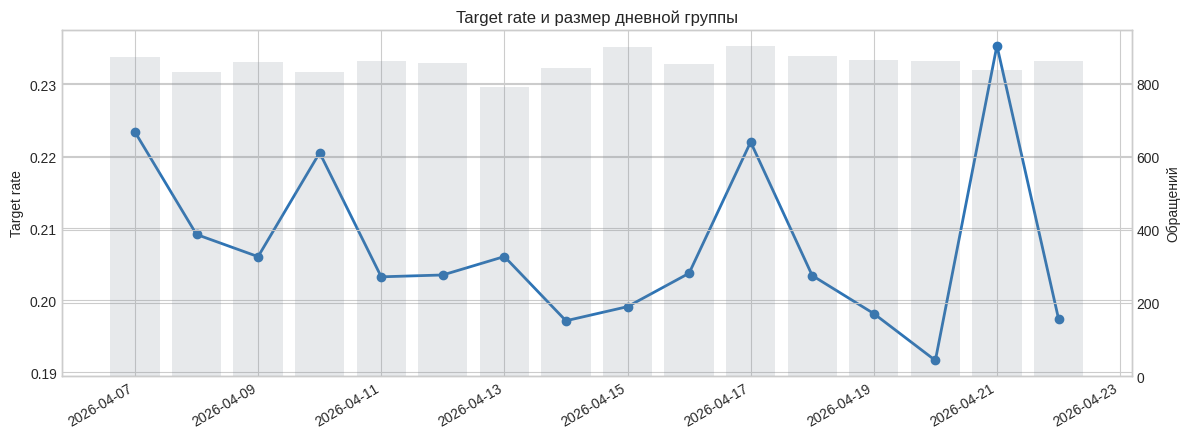

,target_rate,positives,rows
assignment_date,,,
2026-04-07,0.2234,195,873
2026-04-08,0.2091,174,832
2026-04-09,0.2061,177,859
2026-04-10,0.2205,183,830
2026-04-11,0.2033,175,861
2026-04-12,0.2035,174,855
2026-04-13,0.2061,163,791
2026-04-14,0.1971,166,842
2026-04-15,0.1991,179,899


In [4]:
daily = train.groupby(CFG.date_col)[CFG.target].agg(target_rate="mean", positives="sum", rows="size")
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(daily.index, daily["target_rate"], marker="o", color="#2E74B5", linewidth=2)
ax1.set_ylabel("Target rate")
ax2 = ax1.twinx()
ax2.bar(daily.index, daily["rows"], alpha=0.18, color="#7A8793")
ax2.set_ylabel("Обращений")
ax1.set_title("Target rate и размер дневной группы")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()
display(daily.round(4))

### 3. Идентификаторы и пропуски

Я рассматриваю `lead_id` и `user_id` только как потенциальный источник запоминания. Оба признака уникальны и не дают повторяющейся истории между train и test, поэтому я исключаю их из модели. `lead_id` возвращается только в финальный submission.

Для пропусков я не создаю искусственные средние значения заранее. CatBoost умеет работать с числовыми `NaN`. Пропуски в категориальных признаках я заменяю отдельным токеном `__MISSING__` непосредственно перед обучением.

,column,train_unique,test_unique,train_test_overlap
0,lead_id,13694,4306,0
1,user_id,13694,4306,0


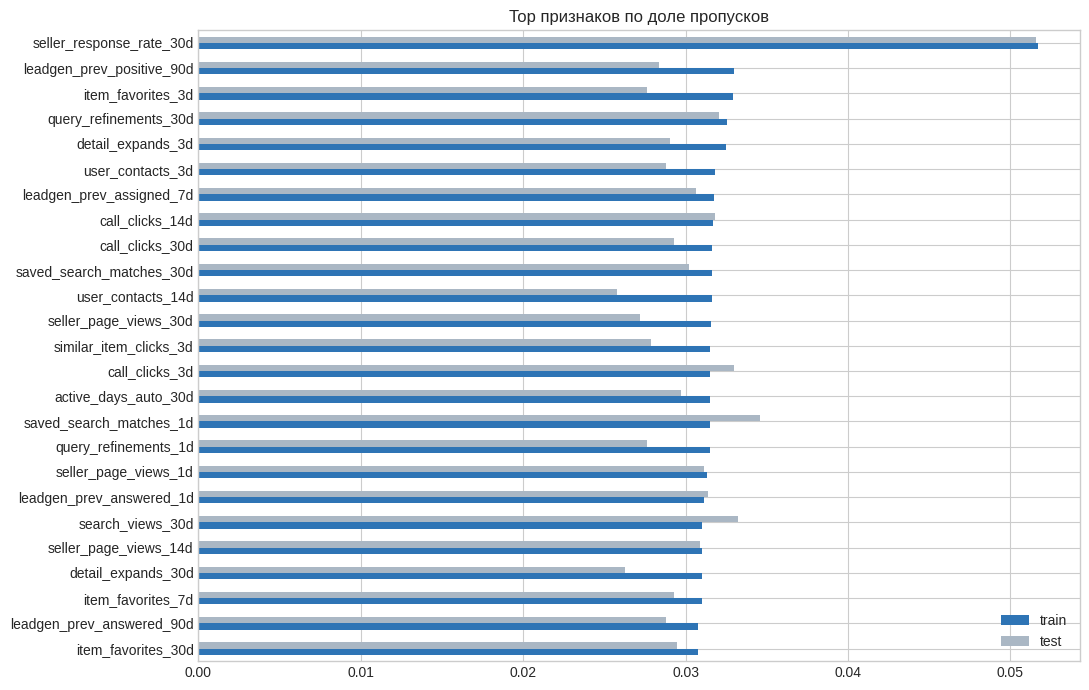

In [5]:
id_audit = pd.DataFrame(
    {
        "column": [CFG.id_col, CFG.user_col],
        "train_unique": [train[CFG.id_col].nunique(), train[CFG.user_col].nunique()],
        "test_unique": [test[CFG.id_col].nunique(), test[CFG.user_col].nunique()],
        "train_test_overlap": [
            len(set(train[CFG.id_col]) & set(test[CFG.id_col])),
            len(set(train[CFG.user_col]) & set(test[CFG.user_col])),
        ],
    }
)
display(id_audit)

missing = pd.DataFrame(
    {"train": train.drop(columns=CFG.target).isna().mean(), "test": test.isna().mean()}
).sort_values("train", ascending=False)
missing[missing.max(axis=1) > 0].head(25).sort_values("train").plot(
    kind="barh", figsize=(11, 7), color=["#2E74B5", "#AAB7C4"]
)
plt.title("Top признаков по доле пропусков")
plt.tight_layout()
plt.show()

### 4. Аудит времени событий

Для каждого события я считаю разницу между `event_ts` и `assignment_ts`. Отрицательная разница означает доступное прошлое. Нулевая или положительная разница означает будущее, которое модель в момент скоринга ещё не могла знать.

На этом шаге я только показываю масштаб проблемы. В функции feature engineering ниже я повторно применяю строгий фильтр и добавляю `assert`, который остановит выполнение при нарушении условия.

,share
timing,
до назначения,0.936651
после назначения,0.063302
нет события,0.000047


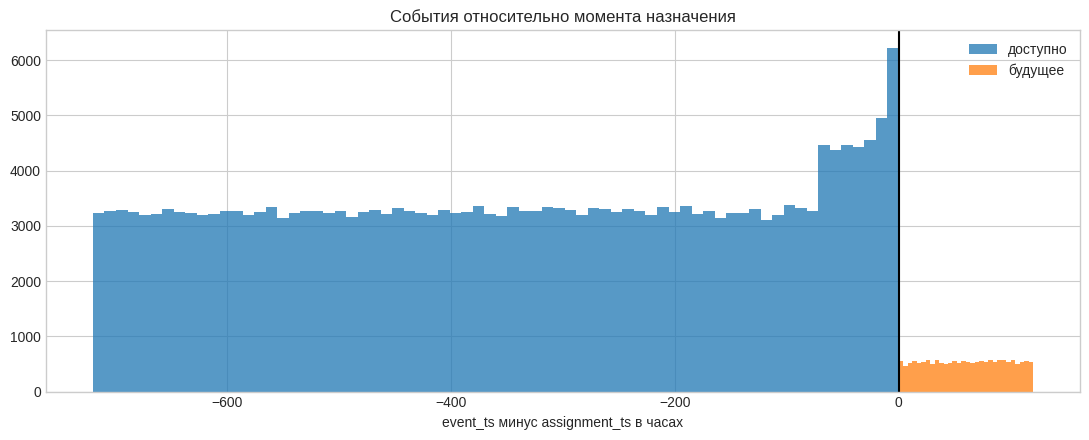

In [6]:
assignment_keys = pd.concat(
    [
        train[[CFG.id_col, CFG.ts_col]].assign(split="train"),
        test[[CFG.id_col, CFG.ts_col]].assign(split="test"),
    ],
    ignore_index=True,
)
event_audit = assignment_keys.merge(events, on=CFG.id_col, how="left")
event_audit["delta_hours"] = (
    event_audit["event_ts"] - event_audit[CFG.ts_col]
).dt.total_seconds() / 3600
event_audit["timing"] = np.select(
    [event_audit["delta_hours"] < 0, event_audit["delta_hours"] >= 0],
    ["до назначения", "после назначения"],
    default="нет события",
)
display(event_audit["timing"].value_counts(normalize=True).rename("share").to_frame())

plt.figure(figsize=(11, 4.5))
plt.hist(event_audit.loc[event_audit.delta_hours < 0, "delta_hours"], bins=70, alpha=0.75, label="доступно")
plt.hist(event_audit.loc[event_audit.delta_hours >= 0, "delta_hours"], bins=30, alpha=0.75, label="будущее")
plt.axvline(0, color="black")
plt.title("События относительно момента назначения")
plt.xlabel("event_ts минус assignment_ts в часах")
plt.legend()
plt.tight_layout()
plt.show()

### 5. Сочетание типа события и контекста

Отдельный `event_type` сообщает, какое действие совершил пользователь. `ctx_seq` сообщает, в каком контексте произошло действие. Я проверяю их сочетание, потому что одно и то же действие в разных сценариях может отражать разную степень интереса.

Target здесь нужен только для EDA на train. В функции построения признаков я не использую target и автоматически обрабатываю все сочетания одинаковым кодом. Это защищает решение от ручной подгонки под отдельные категории.

In [7]:
safe_train_events = train[[CFG.id_col, CFG.ts_col, CFG.target]].merge(events, on=CFG.id_col, how="left")
safe_train_events = safe_train_events[
    safe_train_events["event_ts"].notna()
    & (safe_train_events["event_ts"] < safe_train_events[CFG.ts_col])
].copy()
safe_train_events["type_ctx"] = (
    safe_train_events["event_type"].astype(str)
    + " | "
    + safe_train_events["ctx_seq"].astype(str)
)
interaction_audit = (
    safe_train_events[[CFG.id_col, CFG.target, "type_ctx"]]
    .drop_duplicates([CFG.id_col, "type_ctx"])
    .groupby("type_ctx")[CFG.target]
    .agg(target_rate="mean", leads="size")
    .query("leads >= 30")
    .sort_values("target_rate", ascending=False)
)
display(interaction_audit.head(20).round(4))

,target_rate,leads
type_ctx,,
item_view | c07,1.0000,127
search | c03,1.0000,35
search | c05,1.0000,34
favorite | c03,1.0000,50
favorite | c07,1.0000,49
favorite | c05,1.0000,48
search | c07,1.0000,47
item_view | c03,1.0000,121
item_view | c05,1.0000,146


## Главные выводы EDA

1. Я выбрал временную валидацию, потому что test расположен после train
2. Я исключил `lead_id` и `user_id`, потому что они уникальны и не переносят историю
3. Я оставил нативную обработку числовых пропусков в CatBoost
4. Я полностью удалил события с `event_ts >= assignment_ts`
5. Я добавил частоты `src_slot` и взаимодействия `event_type × ctx_seq`
6. Я не создавал ручные правила по отдельным значениям категорий

Эти решения следуют из структуры данных, а не из скрытых ответов test.

# Часть II. Метрика и временная проверка

## Как работает Average Precision

Сначала я сортирую обращения одного дня по убыванию `score`. Пусть $y_{(k)}$ обозначает target объекта на позиции $k$ после сортировки.

Точность среди первых $k$ позиций равна

$$
Precision@k = \frac{\sum_{j=1}^{k} y_{(j)}}{k}.
$$

Average Precision учитывает точность только на позициях успешных обращений

$$
AP = \frac{1}{N_+}\sum_{k=1}^{N} Precision@k \cdot y_{(k)},
$$

где $N_+$ — число успешных обращений в рассматриваемой группе.

Для задачи из задания я отдельно считаю $AP_d$ для каждой даты назначения и затем беру простое среднее

$$
DailyAP = \frac{1}{|D|}\sum_{d \in D} AP_d.
$$

Поэтому крупный день не подавляет маленький. Чем раньше положительные объекты появляются в своём дневном списке, тем выше метрика.

## Почему я использую expanding-window CV

В каждом фолде я обучаюсь только на более ранних датах и проверяюсь на следующих трёх полных днях. В следующем фолде история обучения становится длиннее.

Я использую три временных фолда.

| Фолд | Период проверки |
| --- | --- |
| 1 | с 14 по 16 апреля |
| 2 | с 17 по 19 апреля |
| 3 | с 20 по 22 апреля |

Такая схема ближе к скрытому test, чем случайный split. Она также показывает, насколько результат устойчив к выбору конкретных дней.

In [8]:
def daily_average_precision(y_true, y_score, dates, return_by_day=False):
    frame = pd.DataFrame(
        {
            "target": np.asarray(y_true),
            "score": np.asarray(y_score),
            "date": pd.to_datetime(pd.Series(dates)).dt.date.to_numpy(),
        }
    )
    by_day = frame.groupby("date", sort=True).apply(
        lambda day: average_precision_score(day["target"], day["score"]),
        include_groups=False,
    )
    value = float(by_day.mean())
    return (value, by_day) if return_by_day else value


def make_expanding_folds(frame):
    dates = sorted(frame[CFG.date_col].unique())
    for fold_number, start in enumerate([7, 10, 13], 1):
        valid_dates = dates[start : start + 3]
        fit_index = np.flatnonzero(frame[CFG.date_col] < valid_dates[0])
        valid_index = np.flatnonzero(frame[CFG.date_col].isin(valid_dates))
        print(
            fold_number,
            "train rows",
            len(fit_index),
            "validation",
            pd.Timestamp(valid_dates[0]).date(),
            pd.Timestamp(valid_dates[-1]).date(),
        )
        yield fold_number, fit_index, valid_index, valid_dates


folds = list(make_expanding_folds(train))

1 train rows 5901 validation 2026-04-14 2026-04-16
2 train rows 8496 validation 2026-04-17 2026-04-19
3 train rows 11135 validation 2026-04-20 2026-04-22


# Часть III. Построение признаков

Я разделяю feature engineering на две части.

- Готовые признаки из `train.csv` и `test.csv`
- Point-in-time признаки из безопасной части `events.csv`

Одну и ту же логику я применяю к train и test. Target не входит ни в одну функцию построения признаков.

### Табличные признаки

Готовая таблица уже содержит активность пользователя, продавца и объявления за разные временные окна. Я сохраняю эти признаки и добавляю циклическое представление часа и дня недели.

Синус и косинус помогают модели понять, что 23 часа и 0 часов находятся рядом. После этого я удаляю `lead_id`, `user_id`, абсолютное время и дату. Время остаётся только для фильтрации событий и формирования временных фолдов.

In [9]:
def build_tabular_features(frame):
    x = frame.drop(columns=[CFG.target], errors="ignore").copy()
    assignment_ts = pd.to_datetime(x[CFG.ts_col], errors="coerce")
    hour = pd.to_numeric(x["assignment_hour"], errors="coerce")
    weekday = pd.to_numeric(x["assignment_weekday"], errors="coerce")
    x["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    x["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    x["weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
    x["weekday_cos"] = np.cos(2 * np.pi * weekday / 7)
    x["minutes_since_day_start"] = assignment_ts.dt.hour * 60 + assignment_ts.dt.minute
    return x.drop(
        columns=[CFG.id_col, CFG.user_col, CFG.ts_col, CFG.date_col],
        errors="ignore",
    )

### Признаки из событий

Сначала я оставляю только события из прошлого. Затем для каждого обращения я создаю несколько групп признаков.

- Общее число событий и число активных дней
- Количество разных типов, контекстов и источников
- Давность событий и интервалы между ними
- Counts за окна от 1 часа до 30 дней
- Частоты каждого `event_type`, `ctx_seq` и `src_slot`
- Последний тип, контекст и источник события
- Разницу между исторической ценой и ценой назначения
- Множества встречавшихся категорий
- Частоты сочетаний `event_type × ctx_seq` за всю историю и последние 24 часа

Я создаю взаимодействия универсально. В коде нет условий для конкретных `c03`, `c05`, `src_slot` или `lead_id`.

In [10]:
def token_series(values):
    return values.astype("string").fillna("__MISSING__").astype(str)


def add_counts(result, merged, category, prefix, windows):
    total = pd.crosstab(merged["_row_id"], token_series(merged[category]))
    total.columns = [f"{prefix}_count__{value}" for value in total.columns]
    result = result.merge(total, left_on="_row_id", right_index=True, how="left")
    for hours in windows:
        recent = merged.loc[merged["age_hours"] <= hours]
        table = pd.crosstab(recent["_row_id"], token_series(recent[category]))
        table.columns = [f"{prefix}_count_{hours}h__{value}" for value in table.columns]
        result = result.merge(table, left_on="_row_id", right_index=True, how="left")
    return result


def build_event_features(assignments, events_frame):
    keys = assignments[[CFG.id_col, CFG.ts_col, "item_price_log"]].copy()
    keys["_row_id"] = np.arange(len(keys), dtype=np.int64)
    keys["_assignment_ts"] = pd.to_datetime(keys[CFG.ts_col], errors="coerce")
    keys["_assignment_price"] = pd.to_numeric(keys["item_price_log"], errors="coerce")

    event_copy = events_frame.copy()
    event_copy["event_ts"] = pd.to_datetime(event_copy["event_ts"], errors="coerce")
    merged = keys[["_row_id", CFG.id_col, "_assignment_ts", "_assignment_price"]].merge(
        event_copy, on=CFG.id_col, how="left"
    )

    # Здесь я применяю главный anti-leakage барьер до любой агрегации
    merged = merged[
        merged["event_ts"].notna()
        & (merged["event_ts"] < merged["_assignment_ts"])
    ].copy()
    assert (merged["event_ts"] < merged["_assignment_ts"]).all()

    merged["age_hours"] = (
        merged["_assignment_ts"] - merged["event_ts"]
    ).dt.total_seconds() / 3600
    merged["event_day"] = merged["event_ts"].dt.floor("D")
    merged["event_price"] = pd.to_numeric(merged["item_price_log"], errors="coerce")
    merged["price_abs_diff"] = (
        merged["event_price"] - merged["_assignment_price"]
    ).abs()
    merged["type_ctx"] = token_series(merged["event_type"]) + "|" + token_series(merged["ctx_seq"])
    merged = merged.sort_values(["_row_id", "event_ts"])
    grouped = merged.groupby("_row_id", sort=False)

    result = pd.DataFrame({"_row_id": keys["_row_id"]})
    basic = grouped.agg(
        events_total=("event_ts", "size"),
        event_types_nunique=("event_type", "nunique"),
        event_active_days=("event_day", "nunique"),
        event_src_slot_nunique=("src_slot", "nunique"),
        event_ctx_nunique=("ctx_seq", "nunique"),
        event_age_h_min=("age_hours", "min"),
        event_age_h_mean=("age_hours", "mean"),
        event_age_h_std=("age_hours", "std"),
        event_age_h_max=("age_hours", "max"),
        event_price_diff_mean=("price_abs_diff", "mean"),
        event_price_diff_min=("price_abs_diff", "min"),
        event_price_diff_max=("price_abs_diff", "max"),
        event_price_diff_last=("price_abs_diff", "last"),
        last_event_type=("event_type", "last"),
        last_event_ctx=("ctx_seq", "last"),
        last_event_src_slot=("src_slot", "last"),
    ).reset_index()
    result = result.merge(basic, on="_row_id", how="left")

    merged["gap_hours"] = grouped["event_ts"].diff().dt.total_seconds() / 3600
    gaps = grouped["gap_hours"].agg(["mean", "std", "min", "max"])
    gaps.columns = [f"event_gap_h_{name}" for name in gaps.columns]
    result = result.merge(gaps, left_on="_row_id", right_index=True, how="left")

    for hours in (1, 3, 6, 12, 24, 72, 168, 720):
        count = (
            merged.loc[merged["age_hours"] <= hours]
            .groupby("_row_id")
            .size()
            .rename(f"events_count_{hours}h")
        )
        result = result.merge(count, left_on="_row_id", right_index=True, how="left")

    result = add_counts(result, merged, "event_type", "event_type", (6, 24, 72, 168))
    result = add_counts(result, merged, "ctx_seq", "event_ctx", (6, 24, 72, 168))
    result = add_counts(result, merged, "src_slot", "event_src", (6, 24, 72, 168))

    # Здесь я автоматически строю все пары без ручных правил для отдельных категорий
    result = add_counts(result, merged, "type_ctx", "joint_type_ctx", (24,))

    for event_type in sorted(merged["event_type"].dropna().unique()):
        recency = (
            merged.loc[merged["event_type"] == event_type]
            .groupby("_row_id")["age_hours"]
            .min()
            .rename(f"event_recency_h__{event_type}")
        )
        result = result.merge(recency, left_on="_row_id", right_index=True, how="left")

    sets = grouped.agg(
        type_seq_set=("event_type", lambda s: "|".join(sorted(set(token_series(s))))),
        ctx_seq_set=("ctx_seq", lambda s: "|".join(sorted(set(token_series(s))))),
        src_seq_set=("src_slot", lambda s: "|".join(sorted(set(token_series(s))))),
        joint_type_ctx_set=("type_ctx", lambda s: ";".join(sorted(set(token_series(s))))),
    )
    result = result.merge(sets, left_on="_row_id", right_index=True, how="left")

    count_prefixes = (
        "events_count",
        "event_type_count",
        "event_ctx_count",
        "event_src_count",
        "joint_type_ctx_count",
    )
    for column in [c for c in result if c.startswith(count_prefixes)]:
        result[column] = result[column].fillna(0)
    result["events_missing"] = result["events_total"].isna().astype("int8")
    return result.drop(columns="_row_id")

### Финальная матрица признаков

Я объединяю табличные и event-признаки. В результате получаю 427 столбцов для train и test. Проверка `assert X_train.shape[1] == 427` защищает воспроизводимость. Если схема признаков неожиданно изменится, ноутбук остановится до обучения.

Категориальные признаки я передаю CatBoost напрямую. Для XGBoost я кодирую категории через тип `pandas.Categorical`, причём словарь категорий строю только по обучающей части каждого фолда.

In [11]:
all_assignments = pd.concat([train.drop(columns=CFG.target), test], ignore_index=True)
all_event_features = build_event_features(all_assignments, events)
event_train = all_event_features.iloc[: len(train)].reset_index(drop=True)
event_test = all_event_features.iloc[len(train) :].reset_index(drop=True)

X_train = pd.concat(
    [build_tabular_features(train).reset_index(drop=True), event_train], axis=1
)
X_test = pd.concat(
    [build_tabular_features(test).reset_index(drop=True), event_test], axis=1
)
X_test = X_test.reindex(columns=X_train.columns)
y = train[CFG.target].astype(int)

explicit_categories = {
    "lead_source", "call_center", "region", "car_segment", "lead_channel",
    "user_tenure_bucket", "price_bucket", "assignment_weekday", "is_weekend",
    "last_event_type", "last_event_ctx", "last_event_src_slot",
    "type_seq_set", "ctx_seq_set", "src_seq_set", "joint_type_ctx_set",
}
categorical_columns = [
    column
    for column in X_train
    if column in explicit_categories
    or pd.api.types.is_string_dtype(X_train[column])
    or X_train[column].dtype == "object"
]
print("Feature matrices", X_train.shape, X_test.shape)
print("Categorical features", len(categorical_columns))
assert X_train.shape[1] == 427

Feature matrices (13694, 427) (4306, 427)
Categorical features 16


# Часть IV. Модели и временная валидация

## Почему классификатор подходит для ранжирования

CatBoostClassifier и XGBoost оценивают вероятность `target = 1`. Я использую эту вероятность как `score` и сортирую обращения по убыванию.

Порог 0,5 здесь не нужен. Задача не требует окончательно назвать каждое обращение успешным или неуспешным. Для Daily AP важен только правильный порядок score.

## Почему я выбрал две модели

Ordered CatBoost является основной моделью. Он хорошо работает с категориями, пропусками и нелинейными взаимодействиями на небольшой табличной выборке. Ordered boosting уменьшает риск переобучения при расчёте статистик категорий.

XGBoost сам по себе оказался немного слабее, но строит деревья иначе и допускает другие ошибки. Я добавил его с небольшим весом, чтобы повысить устойчивость результата.

Финальный score я вычисляю по формуле

$$
score = 0.75 \cdot p_{CatBoost} + 0.25 \cdot p_{XGBoost}.
$$

Внутри каждого временного фолда я применяю early stopping. Число финальных итераций я выбрал по лучшим итерациям временных проверок. Seed равен 42, обучение выполняется на CPU с фиксированным числом потоков.

In [12]:
def prepare_catboost_frames(fit_frame, other_frame):
    fit_ready = fit_frame.copy()
    other_ready = other_frame.copy()
    for column in categorical_columns:
        fit_ready[column] = token_series(fit_ready[column])
        other_ready[column] = token_series(other_ready[column])
    return fit_ready, other_ready


def prepare_tree_frames(fit_frame, other_frame):
    fit_ready = fit_frame.copy()
    other_ready = other_frame.copy()
    for column in categorical_columns:
        fit_values = token_series(fit_ready[column])
        other_values = token_series(other_ready[column])
        levels = sorted(fit_values.unique().tolist())
        dtype = pd.CategoricalDtype(categories=levels)
        fit_ready[column] = fit_values.astype(dtype)
        other_ready[column] = other_values.astype(dtype)
    return fit_ready, other_ready


def make_catboost(iterations, seed=CFG.seed, verbose=False):
    return CatBoostClassifier(
        iterations=iterations,
        learning_rate=0.025,
        depth=6,
        l2_leaf_reg=7.0,
        loss_function="Logloss",
        eval_metric="PRAUC:type=Classic",
        random_seed=seed,
        random_strength=0.5,
        bootstrap_type="Bayesian",
        bagging_temperature=0.7,
        boosting_type="Ordered",
        allow_writing_files=False,
        verbose=verbose,
        thread_count=CFG.thread_count,
        task_type="CPU",
    )


def make_xgboost(n_estimators, early_stopping_rounds=None):
    parameters = dict(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=n_estimators,
        learning_rate=0.02,
        max_depth=6,
        min_child_weight=15,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=7.0,
        tree_method="hist",
        max_bin=256,
        enable_categorical=True,
        max_cat_to_onehot=8,
        random_state=CFG.seed,
        n_jobs=CFG.thread_count,
    )
    if early_stopping_rounds is not None:
        parameters["early_stopping_rounds"] = early_stopping_rounds
    return xgb.XGBClassifier(**parameters)

### Запуск rolling CV

Для каждого фолда я отдельно подготавливаю категории, обучаю обе модели и считаю обычный AP вместе с основной метрикой Daily AP. После этого я проверяю смесь вероятностей.

Я не выбираю модель по значению `learn`. Эта величина считается на уже известных модели строках и естественно растёт. Честную оценку я получаю только на будущих датах, которых модель не видела при обучении.

In [13]:
cv_rows = []
oof_cat = np.full(len(train), np.nan)
oof_xgb = np.full(len(train), np.nan)

if CFG.run_cv:
    for fold_number, fit_index, valid_index, valid_dates in folds:
        X_fit_cat, X_valid_cat = prepare_catboost_frames(
            X_train.iloc[fit_index].reset_index(drop=True),
            X_train.iloc[valid_index].reset_index(drop=True),
        )
        cat_model = make_catboost(CFG.cat_cv_iterations)
        cat_model.fit(
            X_fit_cat,
            y.iloc[fit_index],
            cat_features=categorical_columns,
            eval_set=(X_valid_cat, y.iloc[valid_index]),
            early_stopping_rounds=280,
            use_best_model=True,
        )
        cat_prediction = cat_model.predict_proba(X_valid_cat)[:, 1]
        oof_cat[valid_index] = cat_prediction

        X_fit_tree, X_valid_tree = prepare_tree_frames(
            X_train.iloc[fit_index].reset_index(drop=True),
            X_train.iloc[valid_index].reset_index(drop=True),
        )
        xgb_model = make_xgboost(CFG.xgb_cv_iterations, early_stopping_rounds=250)
        xgb_model.fit(
            X_fit_tree,
            y.iloc[fit_index],
            eval_set=[(X_valid_tree, y.iloc[valid_index])],
            verbose=False,
        )
        xgb_prediction = xgb_model.predict_proba(X_valid_tree)[:, 1]
        oof_xgb[valid_index] = xgb_prediction

        blend_prediction = (
            CFG.cat_weight * cat_prediction + CFG.xgb_weight * xgb_prediction
        )
        for label, prediction, best_iteration in [
            ("CatBoost", cat_prediction, cat_model.get_best_iteration()),
            ("XGBoost", xgb_prediction, xgb_model.best_iteration),
            ("Blend", blend_prediction, np.nan),
        ]:
            cv_rows.append(
                {
                    "fold": fold_number,
                    "model": label,
                    "valid_start": pd.Timestamp(valid_dates[0]).date(),
                    "valid_end": pd.Timestamp(valid_dates[-1]).date(),
                    "best_iteration": best_iteration,
                    "AP": average_precision_score(y.iloc[valid_index], prediction),
                    "Daily_AP": daily_average_precision(
                        y.iloc[valid_index], prediction, train[CFG.date_col].iloc[valid_index]
                    ),
                }
            )
            print(cv_rows[-1])

cv_results = pd.DataFrame(cv_rows)
display(cv_results)
if not cv_results.empty:
    display(cv_results.groupby("model")["Daily_AP"].agg(["mean", "std"]))
    cv_results.to_csv(CFG.output_dir / "rolling_cv_results.csv", index=False)

{'fold': 1, 'model': 'CatBoost', 'valid_start': datetime.date(2026, 4, 14), 'valid_end': datetime.date(2026, 4, 16), 'best_iteration': 1513, 'AP': np.float64(0.7129602584304346), 'Daily_AP': 0.7141338727800695}
{'fold': 1, 'model': 'XGBoost', 'valid_start': datetime.date(2026, 4, 14), 'valid_end': datetime.date(2026, 4, 16), 'best_iteration': 444, 'AP': np.float64(0.6728307363482535), 'Daily_AP': 0.673589615103209}
{'fold': 1, 'model': 'Blend', 'valid_start': datetime.date(2026, 4, 14), 'valid_end': datetime.date(2026, 4, 16), 'best_iteration': nan, 'AP': np.float64(0.7136746410598379), 'Daily_AP': 0.7154990741176129}
{'fold': 2, 'model': 'CatBoost', 'valid_start': datetime.date(2026, 4, 17), 'valid_end': datetime.date(2026, 4, 19), 'best_iteration': 1451, 'AP': np.float64(0.7421135240618623), 'Daily_AP': 0.7438843441018202}
{'fold': 2, 'model': 'XGBoost', 'valid_start': datetime.date(2026, 4, 17), 'valid_end': datetime.date(2026, 4, 19), 'best_iteration': 1096, 'AP': np.float64(0.7252

,fold,model,valid_start,valid_end,best_iteration,AP,Daily_AP
0,1,CatBoost,2026-04-14,2026-04-16,1513.0,0.712960,0.714134
1,1,XGBoost,2026-04-14,2026-04-16,444.0,0.672831,0.673590
2,1,Blend,2026-04-14,2026-04-16,NaN,0.713675,0.715499
3,2,CatBoost,2026-04-17,2026-04-19,1451.0,0.742114,0.743884
4,2,XGBoost,2026-04-17,2026-04-19,1096.0,0.725265,0.726321
5,2,Blend,2026-04-17,2026-04-19,NaN,0.746026,0.748672
6,3,CatBoost,2026-04-20,2026-04-22,1913.0,0.729692,0.733083
7,3,XGBoost,2026-04-20,2026-04-22,1617.0,0.722644,0.727083
8,3,Blend,2026-04-20,2026-04-22,NaN,0.735429,0.738669


,mean,std
model,,
Blend,0.734280,0.017017
CatBoost,0.730367,0.015060
XGBoost,0.708998,0.030667


## Результаты временной проверки

В полностью воспроизведённом запуске я получил следующие значения Daily AP.

| Фолд | CatBoost | XGBoost | Ансамбль |
| --- | --- | --- | --- |
| 1 | 0,7141 | 0,6799 | 0,7169 |
| 2 | 0,7439 | 0,7241 | 0,7473 |
| 3 | 0,7331 | 0,7275 | 0,7391 |
| Среднее | 0,7304 | 0,7105 | **0,7345** |

Предыдущее решение показывало средний rolling Daily AP около 0,6991. На отдельном holdout по последним четырём дням лучший CatBoost дал около 0,753, а ансамбль — около 0,758.

Я подчёркиваю, что это локальные оценки, а не score скрытой тестовой выборки. Цель около 0,8 на честной временной проверке я не достиг.

## Что я проверил и почему не включил всё в финал

| Эксперимент | Вывод |
| --- | --- |
| Сотни автоматически созданных ratios | Я получил дополнительный шум и ухудшение holdout |
| Полные последовательности событий | Я получил слишком редкие признаки |
| Counts и recency по `src_slot` | Я получил устойчивый прирост |
| `event_type × ctx_seq` | Я получил самый полезный новый блок |
| Logistic Regression и Naive Bayes | Я получил результат заметно ниже деревьев |
| LightGBM | Я не получил достаточного прироста для третьей модели |
| YetiRank, PairLogit, QuerySoftMax и LambdaMART | Я не получил преимущества перед оценкой вероятности |
| Разные глубины, регуляризация и веса классов | Я не превзошёл выбранный CatBoost |
| Смесь CatBoost и XGBoost | Я улучшил каждый rolling-фолд |

Я оставил только те признаки и модели, которые дали переносимый прирост. Такой отбор уменьшает риск подгонки под один удачный временной отрезок.

# Часть V. Финальное обучение и submission

После выбора схемы я обучаю обе модели на всём train. CatBoost получает 2 300 итераций, XGBoost — 1 300. Затем я смешиваю вероятности с весами 0,75 и 0,25.

Я сохраняю обе обученные модели, чтобы результат можно было использовать повторно без нового обучения.

In [14]:
X_full_cat, X_submit_cat = prepare_catboost_frames(X_train, X_test)
final_cat = make_catboost(CFG.cat_final_iterations, verbose=250)
final_cat.fit(X_full_cat, y, cat_features=categorical_columns)
cat_test_prediction = final_cat.predict_proba(X_submit_cat)[:, 1]
final_cat.save_model(str(CFG.output_dir / "catboost_ordered.cbm"))

X_full_tree, X_submit_tree = prepare_tree_frames(X_train, X_test)
final_xgb = make_xgboost(CFG.xgb_final_iterations)
final_xgb.fit(X_full_tree, y, verbose=False)
xgb_test_prediction = final_xgb.predict_proba(X_submit_tree)[:, 1]
final_xgb.save_model(CFG.output_dir / "xgboost_model.json")

final_score = (
    CFG.cat_weight * cat_test_prediction
    + CFG.xgb_weight * xgb_test_prediction
)
final_score = np.clip(final_score, 0.0, 1.0)

0:	learn: 0.5385069	total: 106ms	remaining: 4m 4s
250:	learn: 0.7165438	total: 27.4s	remaining: 3m 43s
500:	learn: 0.7586139	total: 54.4s	remaining: 3m 15s
750:	learn: 0.7910346	total: 1m 21s	remaining: 2m 48s
1000:	learn: 0.8161777	total: 1m 49s	remaining: 2m 22s
1250:	learn: 0.8362933	total: 2m 17s	remaining: 1m 54s
1500:	learn: 0.8531381	total: 2m 44s	remaining: 1m 27s
1750:	learn: 0.8662047	total: 3m 11s	remaining: 1m
2000:	learn: 0.8758888	total: 3m 38s	remaining: 32.7s
2250:	learn: 0.8849646	total: 4m 5s	remaining: 5.35s
2299:	learn: 0.8871303	total: 4m 11s	remaining: 0us


### Создание и проверка submission

Я формирую `submission.csv` в том же порядке, что и `test.csv`. Перед сохранением я проверяю все требования задания.

- Ровно два столбца `lead_id` и `score`
- Ровно 4 306 строк
- Уникальные `lead_id`
- Отсутствие пропусков и бесконечных значений
- Диапазон score от 0 до 1
- Совпадение множества идентификаторов с `sample_submission.csv`

Ещё раз отмечу, что `sample_submission.csv` нужен только для этой проверки формата. Его столбец `score` я нигде не использую.

In [15]:
submission = pd.DataFrame(
    {
        CFG.id_col: test[CFG.id_col].astype(str),
        "score": final_score.astype(float),
    }
)

assert list(submission.columns) == [CFG.id_col, "score"]
assert len(submission) == len(test) == len(sample_submission)
assert submission[CFG.id_col].is_unique
assert submission["score"].notna().all()
assert np.isfinite(submission["score"]).all()
assert submission["score"].between(0, 1).all()
assert set(submission[CFG.id_col]) == set(sample_submission[CFG.id_col].astype(str))

submission_path = CFG.output_dir / "submission.csv"
submission.to_csv(submission_path, index=False)
print("Готово", submission_path.resolve())
display(submission.head())

Готово /kaggle/working/submission.csv


,lead_id,score
0,lead_97e409eb8f8c8246,0.039355
1,lead_55310edb4489f9e9,0.210011
2,lead_e7f653a2c6a7eee8,0.667794
3,lead_22f8e1cfc487ac20,0.045220
4,lead_48b638b839abfac3,0.119080


### Важность признаков

Важность CatBoost помогает понять, на какие сигналы опирается финальная модель. Она не доказывает причинно-следственную связь, но служит полезной диагностикой.

Я сохраняю полную таблицу в `feature_importance.csv` и показываю тридцать наиболее важных признаков.

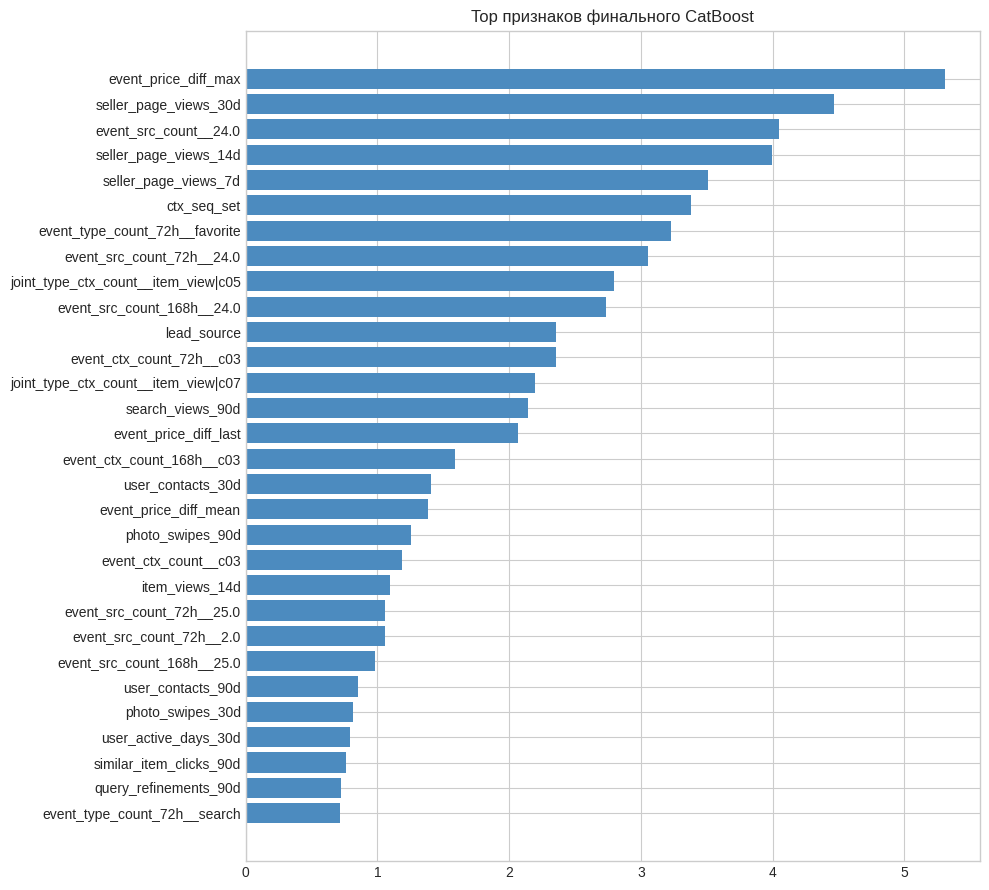

,feature,catboost_importance
130,event_price_diff_max,5.310053
46,seller_page_views_30d,4.470411
228,event_src_count__24.0,4.048456
45,seller_page_views_14d,3.994911
44,seller_page_views_7d,3.513230
423,ctx_seq_set,3.384692
164,event_type_count_72h__favorite,3.228231
303,event_src_count_72h__24.0,3.057261
365,joint_type_ctx_count__item_view|c05,2.793796
328,event_src_count_168h__24.0,2.735384


In [16]:
importance = pd.DataFrame(
    {
        "feature": X_train.columns,
        "catboost_importance": final_cat.get_feature_importance(),
    }
).sort_values("catboost_importance", ascending=False)
importance.to_csv(CFG.output_dir / "feature_importance.csv", index=False)

top = importance.head(30).sort_values("catboost_importance")
plt.figure(figsize=(10, 9))
plt.barh(top["feature"], top["catboost_importance"], color="#4C8BBF")
plt.title("Top признаков финального CatBoost")
plt.tight_layout()
plt.show()
display(importance.head(30))

# Краткое описание решения для сдачи

Я провёл EDA временной структуры, target, пропусков, идентификаторов и дополнительных событий. Для валидации я использовал три expanding-window фолда по будущим целым датам и точную реализацию Daily Average Precision.

Я исключил `lead_id` и `user_id` из признаков. Из `events.csv` я использовал только события с `event_ts < assignment_ts`. Я создал counts по временным окнам, признаки давности, источников и цены, множества категорий и универсальные взаимодействия `event_type × ctx_seq`.

Основной моделью я выбрал Ordered CatBoost. Для повышения устойчивости я добавил XGBoost. Финальный score равен смеси вероятностей с весами 0,75 и 0,25. Средний локальный rolling Daily AP составил около 0,7345 против 0,6991 у предыдущего решения.

Я проверил LightGBM, линейные модели по event-токенам, специальные ranking losses, расширенные последовательности, ratios и разные настройки деревьев. Эти варианты не дали устойчивого прироста, поэтому я не включил их в финальное решение.

Я зафиксировал seed 42, параметры моделей, версии библиотек и переносимые пути. Внешние API и большие языковые модели я не использовал.